In [1]:
#libraries to use 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#read in the dataset 
df = pd.read_csv("ncr_ride_bookings.csv")

In [3]:
#check dataset 
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
#summary of the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [5]:
#creating copy of DF to preserve original and do procesing and transformation on the other
dfClean = df.copy()

In [6]:
#We need to change the datatypes for the following data-types 1) Time: object to time 
dfClean['Time'] = pd.to_datetime(dfClean['Time'], format='%H:%M:%S')
#check 
dfClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  object        
 1   Time                               150000 non-null  datetime64[ns]
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

Our main  gooal is if we are able to predict cancellations 

Data Preprocessing + EDA

In [7]:
#target variable - Creating a new column (Cancelled) that turns messy, multi-column cancellation info into a single clean binary variable.
#A ride is considered cancelled (1) if either the customer or the driver cancels the ride, otherwise (0) it is not cancelled 
#converting the NAN into 0 not canceleld
#Cancelled by Customer/Driver = 1 -> Cancelled to deal with all the ambiguity within the data 
dfClean['Cancelled Rides by Customer'] = dfClean['Cancelled Rides by Customer'].fillna(0)
dfClean['Cancelled Rides by Driver'] = dfClean['Cancelled Rides by Driver'].fillna(0)

#target variable - np where is saying if condition is TRUE assign 1 else assign 0
dfClean['Cancelled'] = np.where(
    (dfClean['Cancelled Rides by Customer'] == 1) | 
    (dfClean['Cancelled Rides by Driver'] == 1),
    1, 0)

#check
print("How Many Rides Were Cancelled VS Not Cancelled?")
dfClean['Cancelled'].value_counts()

How Many Rides Were Cancelled VS Not Cancelled?


Cancelled
0    112500
1     37500
Name: count, dtype: int64

In [8]:
#dealing with missing values by checking what % of missing values per column 
#we are dropping anything over 80% as it is too much missing data and not reliable for modeling and some are even post event info which could have the models cheat thru data leakage
dfClean.isnull().sum().sort_values(ascending=False)
((dfClean.isnull().sum() / len(dfClean)) * 100).round(2).sort_values(ascending=False)

Incomplete Rides                     94.0
Incomplete Rides Reason              94.0
Reason for cancelling by Customer    93.0
Driver Cancellation Reason           82.0
Customer Rating                      38.0
Driver Ratings                       38.0
Payment Method                       32.0
Booking Value                        32.0
Avg CTAT                             32.0
Ride Distance                        32.0
Avg VTAT                              7.0
Date                                  0.0
Time                                  0.0
Booking ID                            0.0
Vehicle Type                          0.0
Customer ID                           0.0
Booking Status                        0.0
Pickup Location                       0.0
Cancelled Rides by Driver             0.0
Cancelled Rides by Customer           0.0
Drop Location                         0.0
Cancelled                             0.0
dtype: float64

In [9]:
#droppoing these columns 
dfClean = dfClean.drop(columns=[
    'Booking ID',
    'Customer ID',
    'Cancelled Rides by Customer',
    'Cancelled Rides by Driver',
    'Reason for cancelling by Customer',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason',
    'Booking Status'
])

In [10]:
#check
dfClean.head(10)

,Date,Time,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled
0,2024-03-23,1900-01-01 12:29:38,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2024-11-29,1900-01-01 18:01:39,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI,0
2,2024-08-23,1900-01-01 08:56:10,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,0
3,2024-10-21,1900-01-01 17:17:25,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,0
4,2024-09-16,1900-01-01 22:08:00,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,0
5,2024-02-06,1900-01-01 09:44:56,Auto,AIIMS,Narsinghpur,5.1,18.1,316.0,4.85,4.1,4.6,UPI,0
6,2024-06-17,1900-01-01 15:45:58,Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,640.0,41.24,4.0,4.1,UPI,0
7,2024-03-19,1900-01-01 17:37:37,Auto,Mayur Vihar,Cyber Hub,12.1,16.5,136.0,6.56,4.4,4.2,UPI,0
8,2024-09-14,1900-01-01 12:49:09,Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,2024-12-16,1900-01-01 19:06:48,Auto,Rohini,Adarsh Nagar,6.1,26.0,135.0,10.36,NaN,NaN,Cash,0


In [11]:
#deal with remaining missing values
dfClean.isnull().sum().sort_values(ascending=False)
((dfClean.isnull().sum() / len(dfClean)) * 100).round(2).sort_values(ascending=False)

Customer Rating    38.0
Driver Ratings     38.0
Avg CTAT           32.0
Booking Value      32.0
Payment Method     32.0
Ride Distance      32.0
Avg VTAT            7.0
Drop Location       0.0
Time                0.0
Date                0.0
Pickup Location     0.0
Vehicle Type        0.0
Cancelled           0.0
dtype: float64

In [12]:
#looking at each columns values to better understand them - we want to investigate the missing values to understand how to clean them 
#this tells me what values exist what does NaN actually mean in each of them 

#how many time each value appears in customer rating
#we can see that 57000 rows have no customer rating 
#how to deal with this ? - the median since median isnt sensitive to outliers
dfClean['Customer Rating'].value_counts(dropna=False)

Customer Rating
NaN    57000
4.9    11642
4.6    11533
4.3    10995
4.2    10697
4.5     5890
4.8     5880
5.0     5837
4.7     5763
4.1     5396
4.4     5279
3.9     2370
3.8     2357
3.7     2354
3.6     1194
4.0     1185
3.1     1008
3.4      928
3.3      900
3.2      881
3.0      468
3.5      443
Name: count, dtype: int64

In [13]:
#how many time each value appears in driver rating
dfClean['Driver Ratings'].value_counts(dropna=False)

Driver Ratings
NaN    57000
4.3    14081
4.2    13841
4.6     9368
4.4     7018
4.1     6966
4.9     4705
4.7     4678
4.5     4634
3.9     3915
3.8     3848
3.7     3790
5.0     2365
4.8     2328
3.6     2026
4.0     1995
3.2     1538
3.4     1491
3.3     1461
3.1     1459
3.5      748
3.0      745
Name: count, dtype: int64

In [14]:
#how many time each value appears in Avg CTAT
dfClean['Avg CTAT'].value_counts(dropna=False)

Avg CTAT
NaN     48000
24.8      401
25.9      389
28.1      388
20.5      386
        ...  
11.6       34
11.1       34
14.5       32
13.8       27
10.0       23
Name: count, Length: 352, dtype: int64

In [15]:
#how many times each value appears in Booking Value
dfClean['Booking Value'].value_counts(dropna=False)

Booking Value
NaN       48000
176.0       177
125.0       174
200.0       170
408.0       169
          ...  
2230.0        1
2078.0        1
3153.0        1
3634.0        1
2903.0        1
Name: count, Length: 2567, dtype: int64

In [16]:
#how many times each value appears in payment method
dfClean['Payment Method'].value_counts(dropna=False)

Payment Method
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

In [17]:
#how many times each value appears in ride distance
dfClean['Ride Distance'].value_counts(dropna=False)

Ride Distance
NaN      48000
17.31       43
9.61        43
14.47       42
12.87       41
         ...  
1.55         1
1.08         1
1.56         1
1.93         1
1.20         1
Name: count, Length: 4902, dtype: int64

In [18]:
#how many tiems each value appears in Avg VTAT
dfClean['Avg VTAT'].value_counts(dropna=False)

Avg VTAT
NaN     10500
9.4      1259
6.0      1249
5.8      1248
9.5      1246
        ...  
19.1       59
19.5       57
18.5       56
18.9       55
20.0       38
Name: count, Length: 182, dtype: int64

In [19]:
#looking at missing vs cancelled 
#Split the dataset into two groups: cancelled rides and not cancelled rides. Then calculate the percent of missing Booking Value in each group.
dfClean.groupby('Cancelled')['Booking Value'].apply(lambda x: x.isnull().mean())

Cancelled
0    0.093333
1    1.000000
Name: Booking Value, dtype: float64

for not cancelled rides -
0.093333 = 9.33% missing Booking Value
for cancelled rides -
0.093333 = 9.33% missing Booking Value
Every cancelled ride is missing Booking Value.

In [20]:
#Split the dataset into two groups: cancelled rides and not cancelled rides. Then calculate the percent of missing ride distance value in each group.
dfClean.groupby('Cancelled')['Ride Distance'].apply(lambda x: x.isnull().mean())


Cancelled
0    0.093333
1    1.000000
Name: Ride Distance, dtype: float64

9.33% of not-cancelled rides are missing ride distance
100% of cancelled rides are missing ride distance
which means cancelled rides do not have ride distance.

In [21]:
#Split the dataset into two groups: cancelled rides and not cancelled rides. Then calculate the percent of missing customer rating value in each group.
dfClean.groupby('Cancelled')['Customer Rating'].apply(lambda x: x.isnull().mean())

Cancelled
0    0.173333
1    1.000000
Name: Customer Rating, dtype: float64

17.33% of not-cancelled rides are missing customer rating
100% of cancelled rides are missing customer rating
Cancelled rides never have customer ratings, and even some non-cancelled rides are missing ratings.


we are able to see right now that when a ride is cancelled a lot of columns become NaN because the ride never happened so these missing values are not random errors they are realinfo bout the ride outtcome 

In [22]:
#officially handling the missing values caused by cacnellation 
#booking value, ride distance, customer rating, driver ratings have missing values because the ride never happened so we are encoding the NaN with 0 because 0 distance
#0 value 0 rating means the ride never happened so this is what we are encoding
dfClean['Booking Value'] = dfClean['Booking Value'].fillna(0)
dfClean['Ride Distance'] = dfClean['Ride Distance'].fillna(0)
dfClean['Customer Rating'] = dfClean['Customer Rating'].fillna(0)
dfClean['Driver Ratings'] = dfClean['Driver Ratings'].fillna(0)

In [23]:
#handling the categorical missing values 
#no ride = no payment method = unknown to preserve this to prevent model cheating
dfClean['Payment Method'] = dfClean['Payment Method'].fillna('Unknown')

In [24]:
#handling true numeric missing values 
#using median since median isnt sensitive to outliers
#these values were missing due to noise and dealing with them by filling with median
dfClean['Avg CTAT'] = dfClean['Avg CTAT'].fillna(dfClean['Avg CTAT'].median())
dfClean['Avg VTAT'] = dfClean['Avg VTAT'].fillna(dfClean['Avg VTAT'].median())

In [25]:
#checking the dataset now 
dfClean.isnull().sum()

Date               0
Time               0
Vehicle Type       0
Pickup Location    0
Drop Location      0
Avg VTAT           0
Avg CTAT           0
Booking Value      0
Ride Distance      0
Driver Ratings     0
Customer Rating    0
Payment Method     0
Cancelled          0
dtype: int64

In [26]:
#check df 
dfClean.head(5)

,Date,Time,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled
0,2024-03-23,1900-01-01 12:29:38,eBike,Palam Vihar,Jhilmil,8.3,28.8,0.0,0.00,0.0,0.0,Unknown,0
1,2024-11-29,1900-01-01 18:01:39,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,0.0,0.0,UPI,0
2,2024-08-23,1900-01-01 08:56:10,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,0
3,2024-10-21,1900-01-01 17:17:25,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,0
4,2024-09-16,1900-01-01 22:08:00,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,0


In [27]:
#extracting the hour from the time colummn to see if any meaning data with day or night time cancellations storing in new column HOUR (essentially time of day pattern)
dfClean['Hour'] = dfClean['Time'].dt.hour

In [28]:
#extractin day of the week so model can learn weekens vs weekdays maybe  patterns of cancellations
dfClean['Date'] = pd.to_datetime(dfClean['Date'])
dfClean['DayOfWeek'] = dfClean['Date'].dt.dayofweek

In [29]:
#dropping original data and time 
dfClean = dfClean.drop(columns=['Date', 'Time'])

In [30]:
#converting categorical variables into numerical format using one-hot encoding
dfClean = pd.get_dummies(dfClean, drop_first=True)

In [31]:
#check 
dfClean.head(5)

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Cancelled,Hour,DayOfWeek,Vehicle Type_Bike,...,Drop Location_Vidhan Sabha,Drop Location_Vinobapuri,Drop Location_Vishwavidyalaya,Drop Location_Welcome,Drop Location_Yamuna Bank,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,Payment Method_Unknown
0,8.3,28.8,0.0,0.00,0.0,0.0,0,12,5,False,...,False,False,False,False,False,False,False,False,False,True
1,4.9,14.0,237.0,5.73,0.0,0.0,0,18,4,False,...,False,False,False,False,False,False,False,True,False,False
2,13.4,25.8,627.0,13.58,4.9,4.9,0,8,4,False,...,False,False,False,False,False,False,True,False,False,False
3,13.1,28.5,416.0,34.02,4.6,5.0,0,17,0,False,...,False,False,False,False,False,False,False,True,False,False
4,5.3,19.6,737.0,48.21,4.1,4.3,0,22,0,True,...,False,False,False,False,False,False,False,True,False,False


In [32]:
#copying to run models and eda on the clean dataset 
finalDF = dfClean.copy()
#check 
finalDF.head(5)

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Cancelled,Hour,DayOfWeek,Vehicle Type_Bike,...,Drop Location_Vidhan Sabha,Drop Location_Vinobapuri,Drop Location_Vishwavidyalaya,Drop Location_Welcome,Drop Location_Yamuna Bank,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,Payment Method_Unknown
0,8.3,28.8,0.0,0.00,0.0,0.0,0,12,5,False,...,False,False,False,False,False,False,False,False,False,True
1,4.9,14.0,237.0,5.73,0.0,0.0,0,18,4,False,...,False,False,False,False,False,False,False,True,False,False
2,13.4,25.8,627.0,13.58,4.9,4.9,0,8,4,False,...,False,False,False,False,False,False,True,False,False,False
3,13.1,28.5,416.0,34.02,4.6,5.0,0,17,0,False,...,False,False,False,False,False,False,False,True,False,False
4,5.3,19.6,737.0,48.21,4.1,4.3,0,22,0,True,...,False,False,False,False,False,False,False,True,False,False


In [33]:
#correlation heatmap with target variable 
#which features are most related to cancellation
corr_with_target = finalDF.corr()['Cancelled'].sort_values(ascending=False)
print(corr_with_target.head(10))

Cancelled                           1.000000
Payment Method_Unknown              0.841625
Avg VTAT                            0.072891
Drop Location_Vasant Kunj           0.011084
Drop Location_Gurgaon Sector 29     0.008369
Pickup Location_Vinobapuri          0.007972
Pickup Location_Akshardham          0.007896
Drop Location_Keshav Puram          0.006451
Drop Location_Bhikaji Cama Place    0.006296
Pickup Location_Munirka             0.005917
Name: Cancelled, dtype: float64


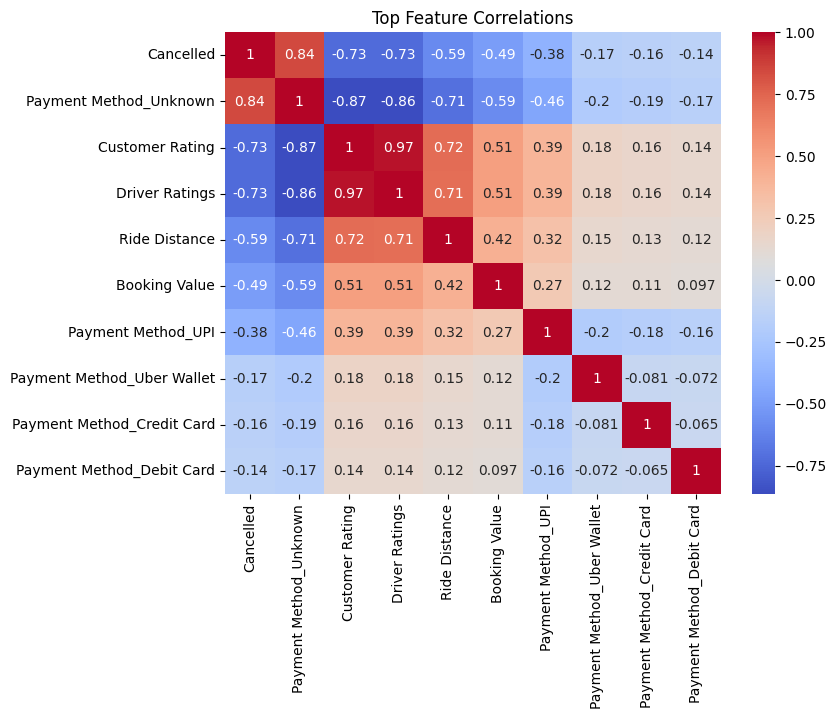

In [34]:
#top features only 
top_features = corr_with_target.abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(8,6))
sns.heatmap(finalDF[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top Feature Correlations")
plt.show()

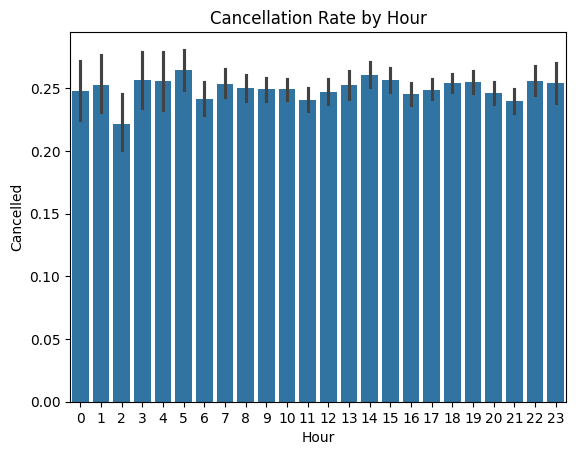

In [35]:
#cancellation by hour 
sns.barplot(x='Hour', y='Cancelled', data=finalDF)
plt.title("Cancellation Rate by Hour")
plt.show()

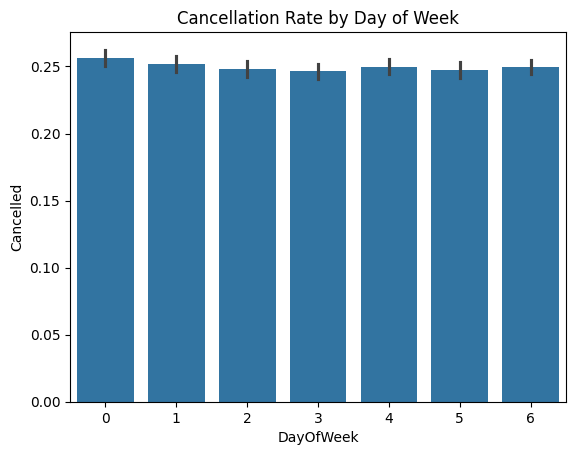

In [36]:
#cancellation by day of week 
sns.barplot(x='DayOfWeek', y='Cancelled', data=finalDF)
plt.title("Cancellation Rate by Day of Week")
plt.show()

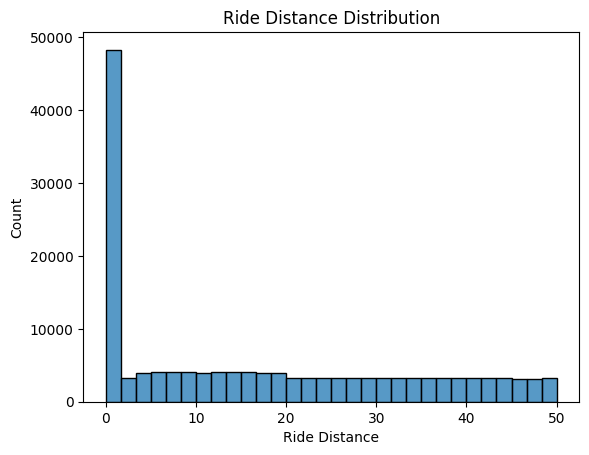

In [37]:
#distribution of ride distance 
sns.histplot(finalDF['Ride Distance'], bins=30)
plt.title("Ride Distance Distribution")
plt.show()

In [38]:
#cancellation vs vehicle type 
vehicle_cols = [col for col in finalDF.columns if 'Vehicle Type' in col]

finalDF[vehicle_cols + ['Cancelled']].groupby('Cancelled').mean()

,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike
Cancelled,,,,,,
0,0.149911,0.198924,0.180249,0.120844,0.029867,0.070462
1,0.150720,0.198053,0.183013,0.120427,0.029040,0.070133


In [39]:
#scaling features to make sure df is consistent 
#x contains all input variables used to predict cancellations
#y is the target variable
X=finalDF.drop('Cancelled',axis=1)
y=finalDF['Cancelled']

#Train/test split
#split the dataset into training (80%) and testing (20%)
#stratify=y ensures class distribution (cancelled vs not cancelled) stays consistent 
#because your target is 75% not cancelled and 25% cancelled. This keeps the same class balance in both training and testing sets.
from sklearn.model_selection import train_test_split


XTrain, XTest, yTrain, yTest = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#feature scaling
#StandardScaler standardizes features to have mean = 0 and std = 1
#this is important for models like KNN and Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)


In [40]:
#check if work was split correctly 
print(XTrain.shape)
print(XTest.shape)
print(yTrain.value_counts(normalize=True))
print(yTest.value_counts(normalize=True))

(120000, 369)
(30000, 369)
Cancelled
0    0.75
1    0.25
Name: proportion, dtype: float64
Cancelled
0    0.75
1    0.25
Name: proportion, dtype: float64


The dataset was split into training (80%) and testing (20%) sets. Stratified sampling was used to preserve the class distribution of the target variable, ensuring both sets maintained a 75% non-cancelled and 25% cancelled ratio.

Data Modeling

In [41]:
#model selection this runs 
#Import model/evaluation libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#List of models to compare
models = [
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('Naive Bayes', GaussianNB()),
    ('KNN', KNeighborsClassifier()),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SGD Classifier', SGDClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]

#Store model results
results = []

#Loop through each model
for name, model in models:
    
    #Train model using scaled training data
    model.fit(XTrainScaled, yTrain)
    
    #Predict on scaled testing data
    yPred = model.predict(XTestScaled)
    
    #Calculate evaluation metrics
    accuracy = accuracy_score(yTest, yPred)
    precision = precision_score(yTest, yPred)
    recall = recall_score(yTest, yPred)
    f1 = f1_score(yTest, yPred)
    
    #Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

#Convert results into a DataFrame
modelResults = pd.DataFrame(results)

#Sort by F1 Score
modelResults = modelResults.sort_values(by='F1 Score', ascending=False)

#Print
modelResults

,Model,Accuracy,Precision,Recall,F1 Score
6,Gradient Boosting,0.997400,1.000000,0.989600,0.994773
5,XGBoost,0.997400,1.000000,0.989600,0.994773
3,Random Forest,0.997400,1.000000,0.989600,0.994773
0,Logistic Regression,0.929500,0.780031,1.000000,0.876424
1,Naive Bayes,0.929500,0.780031,1.000000,0.876424
4,SGD Classifier,0.926467,0.779869,0.983467,0.869914
2,KNN,0.744567,0.479569,0.255067,0.333014


In [42]:
#Logistic Regression
from sklearn.metrics import confusion_matrix

model_lr = LogisticRegression(max_iter=1000, random_state=42)

model_lr.fit(XTrainScaled, yTrain)

yPred_lr = model_lr.predict(XTestScaled)

print("LOGISTIC REGRESSION - FULL DATASET")
print(confusion_matrix(yTest, yPred_lr))
print(classification_report(yTest, yPred_lr))

LOGISTIC REGRESSION - FULL DATASET
[[20385  2115]
 [    0  7500]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     22500
           1       0.78      1.00      0.88      7500

    accuracy                           0.93     30000
   macro avg       0.89      0.95      0.91     30000
weighted avg       0.95      0.93      0.93     30000



In [43]:
#XGBoost
model_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(XTrainScaled, yTrain)

yPred_xgb = model_xgb.predict(XTestScaled)

print("XGBOOST - FULL DATASET")
print(confusion_matrix(yTest, yPred_xgb))
print(classification_report(yTest, yPred_xgb))

XGBOOST - FULL DATASET
[[22500     0]
 [   78  7422]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22500
           1       1.00      0.99      0.99      7500

    accuracy                           1.00     30000
   macro avg       1.00      0.99      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [44]:
#kNN
model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(XTrainScaled, yTrain)

yPred_knn = model_knn.predict(XTestScaled)

print("KNN - FULL DATASET")
print(confusion_matrix(yTest, yPred_knn))
print(classification_report(yTest, yPred_knn))

KNN - FULL DATASET
[[20424  2076]
 [ 5587  1913]]
              precision    recall  f1-score   support

           0       0.79      0.91      0.84     22500
           1       0.48      0.26      0.33      7500

    accuracy                           0.74     30000
   macro avg       0.63      0.58      0.59     30000
weighted avg       0.71      0.74      0.71     30000



PREBOOKING DF TESTING SAMPLE

In [45]:
#we notice rn that their might be data leakage or dataset is very easy to classift rn so we are going to check and compare with a version of the df that is before booking meaning, "can we predict cancellation using information avaialable before the ride is complete?"
#PRE-BOOKING MODEL DATASET
#This version removes features that may only be known after the ride outcome.
#This gives a more realistic model because we want to predict cancellation
#before the ride is completed or cancelled.

#Columns that may leak outcome information
leakage_cols = [
    'Booking Value',
    'Ride Distance',
    'Driver Ratings',
    'Customer Rating'
]

#Remove all payment method dummy columns
#Payment Method_Unknown was strongly tied to cancelled rides
payment_cols = [col for col in finalDF.columns if col.startswith('Payment Method_')]

#Create pre-booking dataset
finalDF_prebooking = finalDF.drop(columns=leakage_cols + payment_cols)

# Check new shape
print("Original finalDF shape:", finalDF.shape)
print("Pre-booking finalDF shape:", finalDF_prebooking.shape)


Original finalDF shape: (150000, 370)
Pre-booking finalDF shape: (150000, 361)


In [46]:
#DEFINE FEATURES AND TARGET
X_pre = finalDF_prebooking.drop('Cancelled', axis=1)
y_pre = finalDF_prebooking['Cancelled']

#TRAIN-TEST SPLIT
# Stratify keeps the cancelled/not cancelled class balance the same
# in both training and testing sets.

XTrain_pre, XTest_pre, yTrain_pre, yTest_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=42,
    stratify=y_pre
)

#Check split
print(XTrain_pre.shape)
print(XTest_pre.shape)
print(yTrain_pre.value_counts(normalize=True))
print(yTest_pre.value_counts(normalize=True))
#feature scaling

scaler_pre = StandardScaler()

XTrain_pre_scaled = scaler_pre.fit_transform(XTrain_pre)
XTest_pre_scaled = scaler_pre.transform(XTest_pre)

(120000, 360)
(30000, 360)
Cancelled
0    0.75
1    0.25
Name: proportion, dtype: float64
Cancelled
0    0.75
1    0.25
Name: proportion, dtype: float64


In [47]:
models = [
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('Naive Bayes', GaussianNB()),
    ('KNN', KNeighborsClassifier()),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SGD Classifier', SGDClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]

results_pre = []

for name, model in models:
    
    #Train model
    model.fit(XTrain_pre_scaled, yTrain_pre)
    
    #Predict on test data
    yPred_pre = model.predict(XTest_pre_scaled)
    
    #Calculate metrics
    accuracy = accuracy_score(yTest_pre, yPred_pre)
    precision = precision_score(yTest_pre, yPred_pre, zero_division=0)
    recall = recall_score(yTest_pre, yPred_pre, zero_division=0)
    f1 = f1_score(yTest_pre, yPred_pre, zero_division=0)
    
    #Store results
    results_pre.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

#Convert results to DataFrame
modelResults_pre = pd.DataFrame(results_pre)

#Sort by F1 score
modelResults_pre = modelResults_pre.sort_values(by='F1 Score', ascending=False)


modelResults_pre

,Model,Accuracy,Precision,Recall,F1 Score
6,Gradient Boosting,0.995633,0.992910,0.989600,0.991252
5,XGBoost,0.995633,0.992910,0.989600,0.991252
3,Random Forest,0.995600,0.992909,0.989467,0.991185
1,Naive Bayes,0.889933,0.776257,0.786400,0.781296
2,KNN,0.690533,0.259439,0.128267,0.171663
4,SGD Classifier,0.749533,0.062500,0.000133,0.000266
0,Logistic Regression,0.750000,0.000000,0.000000,0.000000


When using only pre-booking features, several models defaulted to predicting the majority class, resulting in undefined precision. This indicates that cancellation prediction is significantly more challenging without post-ride information, highlighting the importance of feature availability in predictive modeling.

In [48]:
#logistic regression 
logReg_pre = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

logReg_pre.fit(XTrain_pre_scaled, yTrain_pre)

yPred_logReg_pre = logReg_pre.predict(XTest_pre_scaled)

print("LOGISTIC REGRESSION - PRE-BOOKING DATASET")
print("Confusion Matrix:")
print(confusion_matrix(yTest_pre, yPred_logReg_pre))

print("\nClassification Report:")
print(classification_report(yTest_pre, yPred_logReg_pre, zero_division=0))

LOGISTIC REGRESSION - PRE-BOOKING DATASET
Confusion Matrix:
[[12006 10494]
 [ 3701  3799]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.53      0.63     22500
           1       0.27      0.51      0.35      7500

    accuracy                           0.53     30000
   macro avg       0.52      0.52      0.49     30000
weighted avg       0.64      0.53      0.56     30000



In [49]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn_pre = KNeighborsClassifier(n_neighbors=5)

knn_pre.fit(XTrain_pre_scaled, yTrain_pre)

yPred_knn_pre = knn_pre.predict(XTest_pre_scaled)

print("KNN - PRE-BOOKING DATASET")
print("Confusion Matrix:")
print(confusion_matrix(yTest_pre, yPred_knn_pre))

print("\nClassification Report:")
print(classification_report(yTest_pre, yPred_knn_pre, zero_division=0))

KNN - PRE-BOOKING DATASET
Confusion Matrix:
[[19754  2746]
 [ 6538   962]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81     22500
           1       0.26      0.13      0.17      7500

    accuracy                           0.69     30000
   macro avg       0.51      0.50      0.49     30000
weighted avg       0.63      0.69      0.65     30000



In [51]:
#xgboost
xgb_pre = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_pre.fit(XTrain_pre_scaled, yTrain_pre)

yPred_xgb_pre = xgb_pre.predict(XTest_pre_scaled)

print("XGBOOST - PRE-BOOKING DATASET")
print("Confusion Matrix:")
print(confusion_matrix(yTest_pre, yPred_xgb_pre))

print("\nClassification Report:")
print(classification_report(yTest_pre, yPred_xgb_pre, zero_division=0))

XGBOOST - PRE-BOOKING DATASET
Confusion Matrix:
[[22447    53]
 [   78  7422]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22500
           1       0.99      0.99      0.99      7500

    accuracy                           1.00     30000
   macro avg       0.99      0.99      0.99     30000
weighted avg       1.00      1.00      1.00     30000



#Main FINDINGS


-Models trained on the full dataset achieved near-perfect performance, largely due to the inclusion of post-ride features such as booking value and ride distance.

-When restricted to pre-booking features, model performance decreased for simpler models such as Logistic Regression, highlighting the increased difficulty of predicting cancellations using only pre-ride information.

-Tree-based models, particularly XGBoost, maintained high performance even in the pre-booking scenario, demonstrating their ability to capture complex nonlinear relationships in the data.

-KNN performed poorly across both datasets due to the high dimensionality introduced by one-hot encoding, which negatively impacts distance-based methods.



Feature Comparison

In [52]:
#FULL DATASET
corr_full = finalDF.corr(numeric_only=True)['Cancelled'].drop('Cancelled')
top_features_full = corr_full.abs().sort_values(ascending=False).head(10)

print("\nTop Features - FULL DATASET")
print(top_features_full)


#PRE-BOOKING DATASET
corr_pre = finalDF_prebooking.corr(numeric_only=True)['Cancelled'].drop('Cancelled')
top_features_pre = corr_pre.abs().sort_values(ascending=False).head(10)

print("\nTop Features - PRE-BOOKING DATASET")
print(top_features_pre)


Top Features - FULL DATASET
Payment Method_Unknown        0.841625
Customer Rating               0.728064
Driver Ratings                0.727336
Ride Distance                 0.593727
Booking Value                 0.494658
Payment Method_UPI            0.383426
Payment Method_Uber Wallet    0.172371
Payment Method_Credit Card    0.156024
Payment Method_Debit Card     0.139187
Avg VTAT                      0.072891
Name: Cancelled, dtype: float64

Top Features - PRE-BOOKING DATASET
Avg VTAT                            0.072891
Avg CTAT                            0.018693
Drop Location_Vasant Kunj           0.011084
Drop Location_Gurgaon Sector 29     0.008369
Pickup Location_Vinobapuri          0.007972
Pickup Location_Akshardham          0.007896
Drop Location_Panchsheel Park       0.007123
Drop Location_Keshav Puram          0.006451
Pickup Location_Subhash Chowk       0.006376
Drop Location_Bhikaji Cama Place    0.006296
Name: Cancelled, dtype: float64


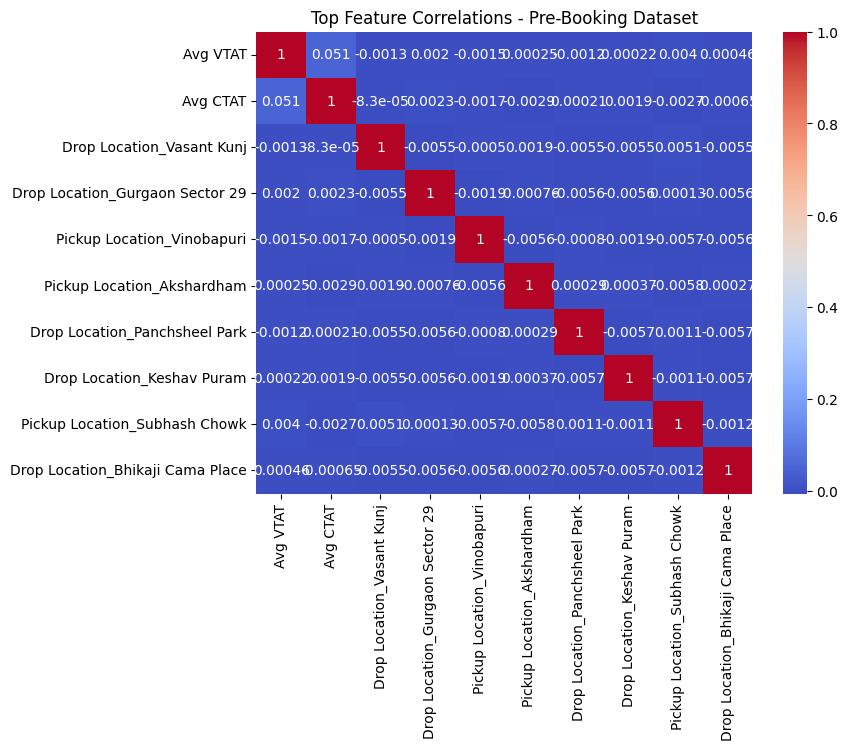

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(finalDF_prebooking[top_features_pre.index].corr(), annot=True, cmap='coolwarm')
plt.title("Top Feature Correlations - Pre-Booking Dataset")
plt.show()

In [55]:
# Compare feature overlap
common_features = set(top_features_full.index).intersection(set(top_features_pre.index))

print("\nCommon Features Between Both Datasets:")
print(common_features)


Common Features Between Both Datasets:
{'Avg VTAT'}
